In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import random
import json
import re
from typing import List, Set, Dict, Tuple, Generator, Iterable
import re
from IPython.display import clear_output, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
### Finalizing Vocabulary ###

vocabulary = []

with open('vocab_copy.json', 'r') as file:
    vocabulary = json.load(file)

vocabulary.append("<|endoftext|>")
vocabulary.append("<unk>")
vocabulary.append("<pad>")

In [11]:
def stream_text_vocab_batches(
    file_path: str,
    vocab: Iterable[str],
    batch: int,
    T: int,
    unk_token: str = "<unk>"
) -> Generator[Tuple[torch.Tensor, torch.Tensor], None, None]:
    """
    Streams tokens from a plain .txt file using custom regex tokenization,
    replaces out-of-vocabulary tokens with `unk_token`, and yields them 
    in batches of shape [batch, T].

    :param file_path: Path to the plain text (.txt) file.
    :param vocab: Iterable of valid vocabulary strings.
    :param batch: Number of sequences per batch.
    :param T: Context window length per sequence.
    :param unk_token: Replacement string for tokens not in `vocab`.
    :return: Yields tuples of (input_tensor, target_tensor) both of shape [batch, T].
    """
    # Convert vocab into a set for checking and a mapping dict for fast indexing
    vocab_list: List[str] = list(vocab)
    vocab_set: Set[str] = set(vocab_list)
    token_to_id: Dict[str, int] = {token: idx for idx, token in enumerate(vocab_list)}
    
    # Pre-calculate unk_token ID
    unk_id: int = token_to_id.get(unk_token, 0)

    # Regex pattern
    pattern = (
        r"<\|endoftext\|>"                    # Captures <|endoftext|> intact
        r"|(?:[A-Za-z]\.){2,}(?:[A-Za-z]\.)?" # Captures abbreviations like U.S.A.
        r"|[A-Za-z]+(?:['\u2019][A-Za-z]+)*"   # Captures words with internal apostrophes
        r"|(?<=[A-Za-z])[.!?]"                 # Captures punctuation at the end of a word
    )

    current_sequence: List[int] = []
    accumulated_data: List[List[int]] = []
    accumulated_answers: List[List[int]] = []

    # Read plain text file line-by-line
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Tokenize plain text line
            raw_tokens = re.findall(pattern, line)

            for token in raw_tokens:
                # Retain case for special tokens, lowercase regular words
                processed_token = token if token == "<|endoftext|>" else token.lower()

                # Fast token lookup
                token_id = token_to_id.get(processed_token, unk_id)
                current_sequence.append(token_id)

                # Build sequences of length T (requires T + 1 tokens for input + target)
                if len(current_sequence) == T + 1:
                    accumulated_data.append(current_sequence[:-1])
                    accumulated_answers.append(current_sequence[1:])
                    
                    # Carry over the last token so sequence context remains continuous
                    current_sequence = current_sequence[-1:]

                    # Yield once we have enough sequences for a batch
                    if len(accumulated_data) == batch:
                        yield torch.tensor(accumulated_data, dtype=torch.long), torch.tensor(accumulated_answers, dtype=torch.long)
                        accumulated_data = []
                        accumulated_answers = []

In [12]:
### Creating Validation Dataset ###

layers = 8
v = len(vocabulary)
T = 256
d = 512
h = 8
batch = 16

path = "/home/aditya/Downloads/TinyStoriesV2-GPT4-valid.txt"

valid_all_data = []

for j, batch_data in tqdm(enumerate(stream_text_vocab_batches(path, vocabulary, batch, T))):
    valid_all_data.append(batch_data)

1204it [00:02, 592.36it/s]


In [13]:
### Forward Pass Functions ###

def encoding_matrix_generator(T, d, device):
    pe = torch.zeros(T, d).to(device)
    position = torch.arange(0, T, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe.unsqueeze(0)

def RMS_Norm(gamma, X, d, epsilon):
    return gamma * (X / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon) )

def A(X, W_k, W_q, T, d, h, mask):
    return torch.softmax( ( ((X@W_q) @ (X@W_k).mT) / ((d/h)**0.5) ).masked_fill(mask==0, float('-inf')) , dim=-1 )

def MHA(X, A, W_v, W_o):
    return (A @ (X@W_v) @ W_o).sum(dim=-3) #### was org dim=1

def MLP(X, W_1, b_1, W_2, b_2):
    return F.leaky_relu((X@W_1 + b_1.unsqueeze(0)), negative_slope=0.01)@W_2 + b_2.unsqueeze(0)

In [14]:
### Cosine Decay Function ###

def get_cosine_with_warmup_lr(current_step, max_lr, min_lr, warmup_steps, total_steps):
    """
    Calculates the learning rate (eta) for a given training step using
    linear warmup followed by sinusoidal cosine decay.
    """
    # Safety check: if we somehow overshoot total steps, return min_lr
    if current_step >= total_steps:
        return min_lr

    # PHASE 1: Linear Warmup
    if current_step < warmup_steps:
        # Avoid division by zero if warmup_steps is set to 0
        if warmup_steps == 0:
            return max_lr
        # Linearly ramp up from 0 to max_lr
        return max_lr * (current_step / warmup_steps)
        
    # PHASE 2: Cosine Decay
    else:
        # Calculate progress through the decay phase
        decay_steps = total_steps - warmup_steps
        current_decay_step = current_step - warmup_steps
        
        # Determine progress fraction from 0.0 to 1.0
        progress = current_decay_step / decay_steps
        
        # Apply the cosine formula
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        
        # Scale the decay between min_lr and max_lr
        return min_lr + (max_lr - min_lr) * cosine_decay

In [15]:
### Backpropagation Functions ###

def Norm_gradient(X, epsilon, delta, batch, T, d):
    return ( delta * (X / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon) ) ).sum(dim=0).sum(dim=0) / batch / T

def Norm_X_gradient(X, gamma, epsilon, delta, d):
    return (( (gamma * delta) - 
            1/d * (X / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon) ) * 
            (RMS_Norm(gamma, X, d, epsilon) * delta).sum(dim=-1, keepdim=True) ) / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon))
    
def W_o_gradient(A, X, W_v, delta, batch, d, h):
    return ( ((torch.cat( ( A @ (X@W_v) ).unbind(1), dim=-1 )).mT @ delta).sum(dim=0) / batch ).view(h, d//h, d)
  
def W_v_gradient(A, X, delta, W_o, batch):
    return (X.mT @ A.mT @ delta @ W_o.mT).sum(dim=0) / batch

def W_q_gradient(A, X, delta, W_o, W_v, W_k, d, h, batch):
    return (X.mT @ (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ) @ (X@W_k) / ((d/h)**0.5)).sum(dim=0) / batch

def W_k_gradient(A, X, delta, W_o, W_v, W_q, d, h, batch):
    return (( (X@W_q).mT @ (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ) @ X ).mT / ((d/h)**0.5)).sum(dim=0) / batch

def X_gradient(A, X, delta, W_o, W_v, W_k, W_q, d, h):
    return (
           (A.mT @ delta @ W_o.mT @ W_v.mT)
           + (1/((d/h)**0.5)) * (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ) @ (X@W_k) @ W_q.mT
           + (1/((d/h)**0.5)) * (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ).mT @ (X@W_q) @ W_k.mT 
           ).sum(dim=1)

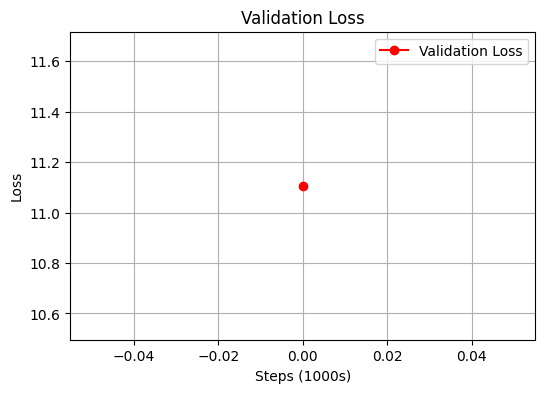

16it [00:23,  1.46s/it]


KeyboardInterrupt: 

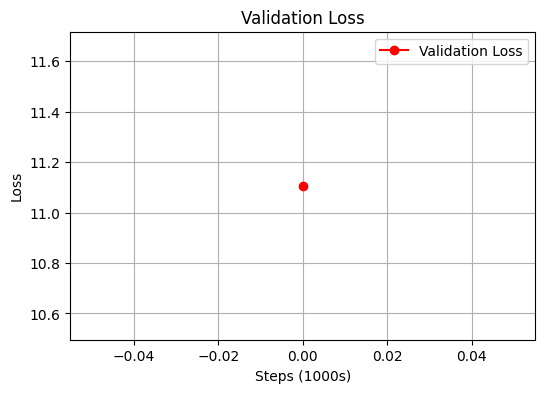

In [16]:
### Algorithm Implementation of General Training ###
"""
layers = 8
v = len(vocabulary)
T = 256
d = 512
h = 8
batch = 16
"""
k = 1.0
beta_1 = 0.9
beta_2 = 0.999
eta = 12.0
eta_max = 3e-4
eta_min = 3e-5
warmup_steps = 1450
total_steps = 145000
lmbda = 0.1 #0.05
epsilon = 1e-8

path = "/home/aditya/Downloads/TinyStoriesV2-GPT4-train.txt"

#one_hot_vecs = torch.zeros(batch, T, v).to(device)
#actual = torch.zeros(batch, T, v).to(device)
embedding_matrix = torch.randn(v, d).to(device) * (1.0 / (d ** 0.5))
encoding_matrix = encoding_matrix_generator(T, d, device)
X_EmbEnc = torch.zeros(batch, T, d).to(device)

mask = torch.tril(torch.ones(T, T, device=device))

W_q = torch.randn(layers, h, d, d//h).to(device) * (2.0 / (d + d//h))**0.5
W_k = torch.randn(layers, h, d, d//h).to(device) * (2.0 / (d + d//h))**0.5
W_v = torch.randn(layers, h, d, d//h).to(device) * (2.0 / (d + d//h))**0.5
W_o = torch.randn(layers, h, d//h, d).to(device) * (2.0 / (d + d//h))**0.5
X_postMHA = torch.zeros(layers, batch, T, d).to(device)
gamma_MHA = torch.ones(layers, d).to(device)

W_1 = torch.randn(layers, d, 4*d).to(device) * (2.0 / d)**0.5
b_1 = torch.zeros(layers, 4*d).to(device)
W_2 = torch.randn(layers, 4*d, d).to(device) * (2.0 / (4*d))**0.5
b_2 = torch.zeros(layers, d).to(device)
X_postMLP = torch.zeros(layers, batch, T, d).to(device)
gamma_MLP = torch.ones(layers, d).to(device)

gamma_out = torch.ones(d,).to(device)
results = torch.rand(batch, T, v).to(device)
loss = []


#embedding_matrix_save = embedding_matrix.clone()
W_q_save = W_q.clone()
W_k_save = W_k.clone()
W_v_save = W_v.clone()
W_o_save = W_o.clone()
gamma_MHA_save = gamma_MHA.clone()
gamma_MLP_save = gamma_MLP.clone()
gamma_out_save = gamma_out.clone()
W_1_save = W_1.clone()
b_1_save = b_1.clone()
W_2_save = W_2.clone()
b_2_save = b_2.clone()

### Gradient Descent Matricies ###
embedding_matrix_velo = torch.zeros(v, d).to(device)
embedding_matrix_sum = torch.zeros(v, d).to(device)
embedding_matrix_grad = torch.zeros(v, d).to(device)

W_q_velo = torch.zeros(layers, h, d, d//h).to(device)
W_q_sum = torch.zeros(layers, h, d, d//h).to(device)
W_q_grad = torch.zeros(layers, h, d, d//h).to(device)

W_k_velo = torch.zeros(layers, h, d, d//h).to(device)
W_k_sum = torch.zeros(layers, h, d, d//h).to(device)
W_k_grad = torch.zeros(layers, h, d, d//h).to(device)

W_v_velo = torch.zeros(layers, h, d, d//h).to(device)
W_v_sum = torch.zeros(layers, h, d, d//h).to(device)
W_v_grad = torch.zeros(layers, h, d, d//h).to(device)

W_o_velo = torch.zeros(layers, h, d//h, d).to(device)
W_o_sum = torch.zeros(layers, h, d//h, d).to(device)
W_o_grad = torch.zeros(layers, h, d//h, d).to(device)

gamma_MHA_velo = torch.zeros(layers, d).to(device)
gamma_MHA_sum = torch.zeros(layers, d).to(device)
gamma_MHA_grad = torch.zeros(layers, d).to(device)

W_1_velo = torch.zeros(layers, d, 4*d).to(device)
W_1_sum = torch.zeros(layers, d, 4*d).to(device)
W_1_grad = torch.zeros(layers, d, 4*d).to(device)

b_1_velo = torch.zeros(layers, 4*d).to(device)
b_1_sum = torch.zeros(layers, 4*d).to(device)
b_1_grad = torch.zeros(layers, 4*d).to(device)

W_2_velo = torch.zeros(layers, 4*d, d).to(device)
W_2_sum = torch.zeros(layers, 4*d, d).to(device)
W_2_grad = torch.zeros(layers, 4*d, d).to(device)

b_2_velo = torch.zeros(layers, d).to(device)
b_2_sum = torch.zeros(layers, d).to(device)
b_2_grad = torch.zeros(layers, d).to(device)

gamma_MLP_velo = torch.zeros(layers, d).to(device)
gamma_MLP_sum = torch.zeros(layers, d).to(device)
gamma_MLP_grad = torch.zeros(layers, d).to(device)

gamma_out_velo = torch.zeros(d,).to(device)
gamma_out_sum = torch.zeros(d,).to(device)
gamma_out_grad = torch.zeros(d,).to(device)

delta = torch.zeros(batch, T, d).to(device)
delta_temp = torch.zeros(batch, T, d).to(device)
#final_one_hot_vecs_mult = torch.zeros(batch, v, d).to(device)

valid_data_indicies = torch.zeros(batch, T).to(device)
valid_answer_indicies = torch.zeros(batch, T).to(device)
batch_loss_store = []
valid_loss = []
steps = []

fig, ax = plt.subplots(figsize=(6, 4))

for j, batch_data in tqdm(enumerate(stream_text_vocab_batches(path, vocabulary, batch, T))): 
    
    embedding_matrix_grad.zero_()
    W_q_grad.zero_()
    W_k_grad.zero_()
    W_v_grad.zero_()
    W_o_grad.zero_()
    gamma_MHA_grad.zero_()
    W_1_grad.zero_()
    b_1_grad.zero_()
    W_2_grad.zero_()
    b_2_grad.zero_()
    gamma_MLP_grad.zero_()
    gamma_out_grad.zero_()

    eta = get_cosine_with_warmup_lr(j, eta_max, eta_min, warmup_steps, total_steps)
    
    """
    Embedding and Encoding
    """
    data_indicies = batch_data[0].to(device)
    answer_indicies = batch_data[1].to(device)

    X_EmbEnc = F.embedding(data_indicies, embedding_matrix) + encoding_matrix
    """
    Transformer Layers
    """
    for i in range(layers):
        if i == 0:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_EmbEnc
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
        else:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_postMLP[i-1]
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]

    """
    Decoding
    """
    results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
    loss.append( F.cross_entropy( (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v), 
                                 answer_indicies.view(-1)).item()) 

    """
    BACKPROPAGATION
    """
    """
    Decoding Backprop
    """
    results[torch.arange(batch).unsqueeze(1), torch.arange(T).unsqueeze(0), answer_indicies] -= 1     # results - actual
 
    embedding_matrix_grad = (( RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon).mT @ (results) ).mT).sum(dim=0) / batch / T ###
    delta = ( (results) @ embedding_matrix ) / T
    
    gamma_out_grad = Norm_gradient(X_postMLP[layers-1], epsilon, delta, batch, T, d)
    gamma_out_velo = beta_1 * gamma_out_velo + (1-beta_1) * gamma_out_grad 
    gamma_out_sum = beta_2 * gamma_out_sum + (1-beta_2) * gamma_out_grad.square()
    
    delta = Norm_X_gradient(X_postMLP[layers-1], gamma_out, epsilon, ( (results) @ embedding_matrix ), d) 
    """
    Transformer Backprop
    """
    for i in reversed(range(layers)):
        W_2_grad[i] = (( F.leaky_relu( (RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                                     negative_slope=0.01) ).mT @ delta).sum(dim=0) / batch
        W_2_velo[i] = beta_1 * W_2_velo[i] + (1-beta_1) * W_2_grad[i]
        W_2_sum[i] = beta_2 * W_2_sum[i] + (1-beta_2) * W_2_grad[i].square()

        b_2_grad[i] = (delta.sum(dim=-2)).sum(dim=0) / batch
        b_2_velo[i] = beta_1 * b_2_velo[i] + (1-beta_1) * b_2_grad[i]
        b_2_sum[i] = beta_2 * b_2_sum[i] + (1-beta_2) * b_2_grad[i].square()

        delta_temp = ((delta @ W_2[i].mT) * 
                ( ( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) >= 0 ).float() 
                + 0.01*( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) < 0 ) ))
     
        W_1_grad[i] = ((RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon)).mT @ delta_temp).sum(dim=0) / batch
        W_1_velo[i] = beta_1 * W_1_velo[i] + (1-beta_1) * W_1_grad[i]
        W_1_sum[i] = beta_2 * W_1_sum[i] + (1-beta_2) * W_1_grad[i].square()

        b_1_grad[i] = (delta_temp.sum(dim=-2)).sum(dim=0) / batch
        b_1_velo[i] = beta_1 * b_1_velo[i] + (1-beta_1) * b_1_grad[i]
        b_1_sum[i] = beta_2 * b_1_sum[i] + (1-beta_2) * b_1_grad[i].square()

        delta_temp = delta_temp @ W_1[i].mT

        gamma_MLP_grad[i] = Norm_gradient(X_postMHA[i], epsilon, delta_temp, batch, T, d)
        gamma_MLP_velo[i] = beta_1 * gamma_MLP_velo[i] + (1-beta_1) * gamma_MLP_grad[i]
        gamma_MLP_sum[i] = beta_2 * gamma_MLP_sum[i] + (1-beta_2) * gamma_MLP_grad[i].square()

        delta = Norm_X_gradient(X_postMHA[i], gamma_MLP[i], epsilon, delta_temp, d) + delta

        if i==0:
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_EmbEnc, epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_EmbEnc, gamma_MHA[i], epsilon, delta_temp, d) + delta
        else:    
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_postMLP[i-1], epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_postMLP[i-1], gamma_MHA[i], epsilon, delta_temp, d) + delta

        
        W_2[i] = (W_2[i] 
                 - eta / ( epsilon + (W_2_sum[i] / (1-beta_2**k)).sqrt() ) * (W_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_2[i])

        b_2[i] = (b_2[i] 
                 - eta / ( epsilon + (b_2_sum[i] / (1-beta_2**k)).sqrt() ) * (b_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_2[i])

        W_1[i] = (W_1[i] 
                 - eta / ( epsilon + (W_1_sum[i] / (1-beta_2**k)).sqrt() ) * (W_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_1[i])

        b_1[i] = (b_1[i] 
                 - eta / ( epsilon + (b_1_sum[i] / (1-beta_2**k)).sqrt() ) * (b_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_1[i])

        gamma_MLP[i] = (gamma_MLP[i] 
                 - eta / ( epsilon + (gamma_MLP_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MLP_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MLP[i])
        
        W_o[i] = (W_o[i] 
                 - eta / ( epsilon + (W_o_sum[i] / (1-beta_2**k)).sqrt() ) * (W_o_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_o[i])

        W_v[i] = (W_v[i] 
                 - eta / ( epsilon + (W_v_sum[i] / (1-beta_2**k)).sqrt() ) * (W_v_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_v[i])
        
        W_k[i] = (W_k[i] 
                 - eta / ( epsilon + (W_k_sum[i] / (1-beta_2**k)).sqrt() ) * (W_k_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_k[i])
        
        W_q[i] = (W_q[i] 
                 - eta / ( epsilon + (W_q_sum[i] / (1-beta_2**k)).sqrt() ) * (W_q_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_q[i])

        gamma_MHA[i] = (gamma_MHA[i] 
                 - eta / ( epsilon + (gamma_MHA_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MHA_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MHA[i])


    # embedding_matrix + one_hot_vecs.mT @ delta
    embedding_matrix_grad = (embedding_matrix_grad.index_add_(dim=0, index=data_indicies.reshape(-1), source=delta.reshape(-1, d)))/batch 
    embedding_matrix_velo = beta_1 * embedding_matrix_velo + (1-beta_1) * embedding_matrix_grad
    embedding_matrix_sum = beta_2 * embedding_matrix_sum + (1-beta_2) * embedding_matrix_grad.square()
    embedding_matrix = (embedding_matrix 
                 - eta / ( epsilon + (embedding_matrix_sum / (1-beta_2**k)).sqrt() ) * (embedding_matrix_velo / (1-beta_1**k))
                 - eta * lmbda * embedding_matrix)
    
    gamma_out = (gamma_out 
                 - eta / ( epsilon + (gamma_out_sum / (1-beta_2**k)).sqrt() ) * (gamma_out_velo / (1-beta_1**k))
                 - eta * lmbda * gamma_out)
    
    
    """
    Validate Every 1000 Batches
    """
    if j%1000 == 0:
        for data_point in random.sample(valid_all_data, 50):

            valid_data_indicies = data_point[0].to(device)
            valid_answer_indicies = data_point[1].to(device)
            
            X_EmbEnc = F.embedding(valid_data_indicies, embedding_matrix) + encoding_matrix
            
            """
            Transformer Layers
            """
            for i in range(layers):
                if i == 0:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_EmbEnc
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
                else:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_postMLP[i-1]
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
            
            """
            Decoding
            """
            results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
            batch_loss_store.append( F.cross_entropy( (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v), 
                                         valid_answer_indicies.view(-1)).item())

        valid_loss.append( sum(batch_loss_store) / len(batch_loss_store) )
        steps.append(j/1000)

        # Clear the old output ONLY when the new plot is ready to render
        clear_output(wait=True)
    
        # Wipe the old line from the axis, but keep the window size intact
        ax.cla()
    
        # Redraw the updated data line
        ax.plot(steps, valid_loss, "r-", marker="o", label="Validation Loss")
        ax.set_title("Validation Loss")
        ax.set_xlabel("Steps (1000s)")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()
    
        # Instantly push the updated figure to the screen
        display(fig)
        
        batch_loss_store = []
    
    k = k+1


print(loss)
print(valid_loss)

Weight_Tensors = { "embedding_matrix" : embedding_matrix,
                   "W_q" : W_q,
                   "W_k" : W_k,
                   "W_v" : W_v,
                   "W_o" : W_o,
                   "gamma_MHA" : gamma_MHA,
                   "W_1" : W_1,
                   "b_1" : b_1,
                   "W_2" : W_2,
                   "b_2" : b_2,
                   "gamma_MLP" : gamma_MLP,
                   "gamma_out" : gamma_out }

torch.save(Weight_Tensors, "LLM_Weights.pt")

In [33]:
### Fine Tuning Generator ###

def stream_json_vocab_batches(
    file_path: str,
    vocab: Iterable[str],
    batch: int,
    T: int,
    unk_token: str = "<unk>",
    sep_token: str = "<sep>",
    eos_token: str = "<|endoftext|>",
    pad_token: str = "<pad>",
) -> Generator[Tuple[torch.Tensor, torch.Tensor, torch.Tensor], None, None]:
    """Streams source-target translation pairs from a JSON/JSONL file,

    tokenizes using custom regex rules, formats sequence outputs, and yields
    batches of (data, answers, mask) tensors of shape [batch, T].

    :param file_path: Path to the JSON or JSONL file.
    :param vocab: Iterable of valid vocabulary strings.
    :param batch: Number of sequences per batch.
    :param T: Context window length per sequence.
    :param unk_token: Replacement string for tokens not in `vocab`.
    :param sep_token: Separator token between source and target text.
    :param eos_token: End-of-sequence token after target text.
    :param pad_token: Padding token to fill sequences up to length T.
    :return: Yields tuples of (data_tensor, answers_tensor, mask_tensor).
    """
    vocab_list: List[str] = list(vocab)
    token_to_id: Dict[str, int] = {token: idx for idx, token in enumerate(vocab_list)}

    # Pre-calculate special token IDs
    unk_id: int = token_to_id.get(unk_token, 0)
    sep_id: int = token_to_id.get(sep_token, unk_id)
    eos_id: int = token_to_id.get(eos_token, unk_id)
    pad_id: int = token_to_id.get(pad_token, unk_id)

    special_tokens: Set[str] = {
        sep_token,
        eos_token,
        pad_token,
        unk_token,
        "<|endoftext|>",
    }

    # Extended regex pattern to preserve special tokens intact
    pattern = (
        r"<[^>]+>"  # Captures special tokens like <sep>, <eos>, <pad>, <unk>
        r"|(?:[A-Za-z]\.){2,}(?:[A-Za-z]\.)?"  # Captures abbreviations like U.S.A.
        r"|[A-Za-z]+(?:['\u2019][A-Za-z]+)*"  # Captures words with internal apostrophes
        r"|(?<=[A-Za-z])[.!?]"  # Captures punctuation at the end of a word
    )

    accumulated_data: List[List[int]] = []
    accumulated_answers: List[List[int]] = []
    accumulated_masks: List[List[int]] = []

    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read().strip()
        # Parse JSON array or JSON Lines format
        if content.startswith("["):
            records = json.loads(content)
        else:
            records = [
                json.loads(line) for line in content.splitlines() if line.strip()
            ]

        for item in records:
            source_text = item.get("source", "")
            target_text = item.get("target", "")

            # Tokenize source and target fields
            raw_source = re.findall(pattern, source_text)
            raw_target = re.findall(pattern, target_text)

            # Map tokens to IDs (retaining case for special tokens)
            source_ids = [
                token_to_id.get(
                    t if t in special_tokens else t.lower(), unk_id
                )
                for t in raw_source
            ]
            target_ids = [
                token_to_id.get(
                    t if t in special_tokens else t.lower(), unk_id
                )
                for t in raw_target
            ]

            # Full sequence: [source] + [<sep>] + [target] + [<eos>]
            full_seq = source_ids + [sep_id] + target_ids + [eos_id]

            # Correct mask logic:
            # - len(source_ids) positions predicting source & <sep> -> mask = 0
            # - 1 position (<sep>) predicting first target token    -> mask = 1
            # - len(target_ids) positions predicting target tokens & <eos> -> mask = 1
            # - 1 position (<eos>) predicting <pad>                 -> mask = 0
            full_mask = [0] * len(source_ids) + [1] * (len(target_ids) + 1) + [0]

            # Pad or truncate to exact context length T
            if len(full_seq) < T:
                padding_len = T - len(full_seq)
                padded_seq = full_seq + [pad_id] * padding_len
                padded_mask = full_mask + [0] * padding_len
            else:
                padded_seq = full_seq[:T]
                padded_mask = full_mask[:T]

            # Target answer sequence (shifted by 1 position for next-token prediction)
            answers_seq = padded_seq[1:] + [pad_id]

            accumulated_data.append(padded_seq)
            accumulated_answers.append(answers_seq)
            accumulated_masks.append(padded_mask)

            # Yield batch once filled
            if len(accumulated_data) == batch:
                yield (
                    torch.tensor(accumulated_data, dtype=torch.long),
                    torch.tensor(accumulated_answers, dtype=torch.long),
                    torch.tensor(accumulated_masks, dtype=torch.long),
                )
                accumulated_data = []
                accumulated_answers = []
                accumulated_masks = []



def make_it_pretty(tokens: List[str]) -> str:
    pretty: List[str] = []
    for t in tokens:
        if t in END_PUNCT and pretty:
            pretty[-1] = pretty[-1] + t
        else:
            pretty.append(t)
    if pretty:
        pretty[0] = pretty[0].capitalize()
    return " ".join(pretty)


In [34]:
layers = 8
v = len(vocabulary)
T = 256
d = 512
h = 8
batch = 16

brainrot_validation_data = []
path = "/home/aditya/Downloads/validation.jsonl"

for batch_data in tqdm(stream_json_vocab_batches(path, vocabulary, batch, T)):
    brainrot_validation_data.append(batch_data)

print(brainrot_validation_data[-1][0].shape)
print(brainrot_validation_data[-1][1].shape)
print(brainrot_validation_data[-1][2].shape)

31it [00:00, 1219.46it/s]

torch.Size([16, 256])
torch.Size([16, 256])
torch.Size([16, 256])


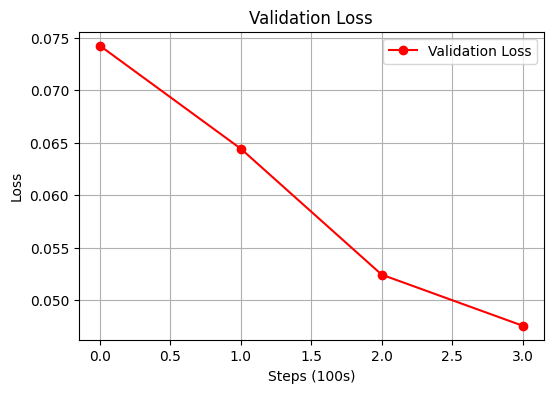

353it [05:58,  1.02s/it]


[15.782852172851562, 15.860980033874512, 15.795337677001953, 15.792590141296387, 15.892094612121582, 15.923797607421875, 15.851593971252441, 15.810495376586914, 15.853263854980469, 15.925187110900879, 15.861133575439453, 15.809133529663086, 15.956353187561035, 15.879206657409668, 15.783254623413086, 15.761740684509277, 15.898672103881836, 15.902503967285156, 15.949309349060059, 16.00104522705078, 15.858527183532715, 15.892731666564941, 15.868542671203613, 15.915518760681152, 15.947988510131836, 15.882288932800293, 15.984708786010742, 15.376626968383789, 15.231891632080078, 15.246415138244629, 15.392483711242676, 15.249460220336914, 15.302215576171875, 15.40494155883789, 15.30958366394043, 15.323165893554688, 15.131312370300293, 15.115280151367188, 14.947271347045898, 14.919692039489746, 15.005437850952148, 14.95716667175293, 15.05922794342041, 15.020182609558105, 14.997135162353516, 15.017638206481934, 14.990477561950684, 14.951683044433594, 15.005043029785156, 15.030649185180664, 14.9

In [38]:
### Fine Tuning Training (Brainrot) ###

vocabulary[-4] = "<sep>"

loaded_weights = torch.load("LLM_Weights.pt", weights_only=True)

k = 1.0
beta_1 = 0.9
beta_2 = 0.999
eta = 12.0
eta_max = 3e-5
eta_min = 3e-6
warmup_steps = 1450
total_steps = 145000
lmbda = 0.1 #0.05
epsilon = 1e-8

# Weights
embedding_matrix = loaded_weights["embedding_matrix"]
W_q = loaded_weights["W_q"]
W_k = loaded_weights["W_k"]
W_v = loaded_weights["W_v"]
W_o = loaded_weights["W_o"]
gamma_MHA = loaded_weights["gamma_MHA"]
W_1 = loaded_weights["W_1"]
b_1 = loaded_weights["b_1"]
W_2 = loaded_weights["W_2"]
b_2 = loaded_weights["b_2"]
gamma_MLP = loaded_weights["gamma_MLP"]
gamma_out = loaded_weights["gamma_out"]

X_EmbEnc = torch.zeros(batch, T, d).to(device)
X_postMHA = torch.zeros(layers, batch, T, d).to(device)
X_postMLP = torch.zeros(layers, batch, T, d).to(device)

path = "/home/aditya/Downloads/train.jsonl"

encoding_matrix = encoding_matrix_generator(T, d, device)

mask = torch.tril(torch.ones(T, T, device=device))

loss = []

### Gradient Descent Matricies ###
sentence_mask = torch.zeros(batch, T).to(device)

embedding_matrix_velo = torch.zeros(v, d).to(device)
embedding_matrix_sum = torch.zeros(v, d).to(device)
embedding_matrix_grad = torch.zeros(v, d).to(device)

W_q_velo = torch.zeros(layers, h, d, d//h).to(device)
W_q_sum = torch.zeros(layers, h, d, d//h).to(device)
W_q_grad = torch.zeros(layers, h, d, d//h).to(device)

W_k_velo = torch.zeros(layers, h, d, d//h).to(device)
W_k_sum = torch.zeros(layers, h, d, d//h).to(device)
W_k_grad = torch.zeros(layers, h, d, d//h).to(device)

W_v_velo = torch.zeros(layers, h, d, d//h).to(device)
W_v_sum = torch.zeros(layers, h, d, d//h).to(device)
W_v_grad = torch.zeros(layers, h, d, d//h).to(device)

W_o_velo = torch.zeros(layers, h, d//h, d).to(device)
W_o_sum = torch.zeros(layers, h, d//h, d).to(device)
W_o_grad = torch.zeros(layers, h, d//h, d).to(device)

gamma_MHA_velo = torch.zeros(layers, d).to(device)
gamma_MHA_sum = torch.zeros(layers, d).to(device)
gamma_MHA_grad = torch.zeros(layers, d).to(device)

W_1_velo = torch.zeros(layers, d, 4*d).to(device)
W_1_sum = torch.zeros(layers, d, 4*d).to(device)
W_1_grad = torch.zeros(layers, d, 4*d).to(device)

b_1_velo = torch.zeros(layers, 4*d).to(device)
b_1_sum = torch.zeros(layers, 4*d).to(device)
b_1_grad = torch.zeros(layers, 4*d).to(device)

W_2_velo = torch.zeros(layers, 4*d, d).to(device)
W_2_sum = torch.zeros(layers, 4*d, d).to(device)
W_2_grad = torch.zeros(layers, 4*d, d).to(device)

b_2_velo = torch.zeros(layers, d).to(device)
b_2_sum = torch.zeros(layers, d).to(device)
b_2_grad = torch.zeros(layers, d).to(device)

gamma_MLP_velo = torch.zeros(layers, d).to(device)
gamma_MLP_sum = torch.zeros(layers, d).to(device)
gamma_MLP_grad = torch.zeros(layers, d).to(device)

gamma_out_velo = torch.zeros(d,).to(device)
gamma_out_sum = torch.zeros(d,).to(device)
gamma_out_grad = torch.zeros(d,).to(device)

delta = torch.zeros(batch, T, d).to(device)
delta_temp = torch.zeros(batch, T, d).to(device)

valid_data_indicies = torch.zeros(batch, T).to(device)
valid_answer_indicies = torch.zeros(batch, T).to(device)
batch_loss_store = []
valid_loss = []
steps = []

for j, batch_data in tqdm(enumerate(stream_json_vocab_batches(path, vocabulary, batch, T))): 
    
    embedding_matrix_grad.zero_()
    W_q_grad.zero_()
    W_k_grad.zero_()
    W_v_grad.zero_()
    W_o_grad.zero_()
    gamma_MHA_grad.zero_()
    W_1_grad.zero_()
    b_1_grad.zero_()
    W_2_grad.zero_()
    b_2_grad.zero_()
    gamma_MLP_grad.zero_()
    gamma_out_grad.zero_()

    eta = get_cosine_with_warmup_lr(j, eta_max, eta_min, warmup_steps, total_steps)
    
    """
    Embedding and Encoding
    """
    data_indicies = batch_data[0].to(device)
    answer_indicies = batch_data[1].to(device)
    sentence_mask = batch_data[2].to(device)

    X_EmbEnc = F.embedding(data_indicies, embedding_matrix) + encoding_matrix
    """
    Transformer Layers
    """
    for i in range(layers):
        if i == 0:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_EmbEnc
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
        else:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_postMLP[i-1]
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]

    """
    Decoding
    """
    results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
    loss.append( F.cross_entropy( (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v), 
                                 answer_indicies.view(-1)).item()) 

    """
    BACKPROPAGATION
    """
    
    """
    Decoding Backprop
    """
    results[torch.arange(batch).unsqueeze(1), torch.arange(T).unsqueeze(0), answer_indicies] -= 1     # results - actual

    results = (sentence_mask.unsqueeze(-1) * results) / sentence_mask.sum() * batch                   # apply mask
    
    embedding_matrix_grad = (( RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon).mT @ (results) ).mT).sum(dim=0)  ###
    delta = ( (results) @ embedding_matrix )                                                                         ###
    
    gamma_out_grad = Norm_gradient(X_postMLP[layers-1], epsilon, delta, batch, T, d)
    gamma_out_velo = beta_1 * gamma_out_velo + (1-beta_1) * gamma_out_grad 
    gamma_out_sum = beta_2 * gamma_out_sum + (1-beta_2) * gamma_out_grad.square()
    
    delta = Norm_X_gradient(X_postMLP[layers-1], gamma_out, epsilon, ( (results) @ embedding_matrix ), d) 
    """
    Transformer Backprop
    """
    for i in reversed(range(layers)):
        W_2_grad[i] = (( F.leaky_relu( (RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                                     negative_slope=0.01) ).mT @ delta).sum(dim=0) / batch
        W_2_velo[i] = beta_1 * W_2_velo[i] + (1-beta_1) * W_2_grad[i]
        W_2_sum[i] = beta_2 * W_2_sum[i] + (1-beta_2) * W_2_grad[i].square()

        b_2_grad[i] = (delta.sum(dim=-2)).sum(dim=0) / batch
        b_2_velo[i] = beta_1 * b_2_velo[i] + (1-beta_1) * b_2_grad[i]
        b_2_sum[i] = beta_2 * b_2_sum[i] + (1-beta_2) * b_2_grad[i].square()

        delta_temp = ((delta @ W_2[i].mT) * 
                ( ( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) >= 0 ).float() 
                + 0.01*( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) < 0 ) ))
     
        W_1_grad[i] = ((RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon)).mT @ delta_temp).sum(dim=0) / batch
        W_1_velo[i] = beta_1 * W_1_velo[i] + (1-beta_1) * W_1_grad[i]
        W_1_sum[i] = beta_2 * W_1_sum[i] + (1-beta_2) * W_1_grad[i].square()

        b_1_grad[i] = (delta_temp.sum(dim=-2)).sum(dim=0) / batch
        b_1_velo[i] = beta_1 * b_1_velo[i] + (1-beta_1) * b_1_grad[i]
        b_1_sum[i] = beta_2 * b_1_sum[i] + (1-beta_2) * b_1_grad[i].square()

        delta_temp = delta_temp @ W_1[i].mT

        gamma_MLP_grad[i] = Norm_gradient(X_postMHA[i], epsilon, delta_temp, batch, T, d)
        gamma_MLP_velo[i] = beta_1 * gamma_MLP_velo[i] + (1-beta_1) * gamma_MLP_grad[i]
        gamma_MLP_sum[i] = beta_2 * gamma_MLP_sum[i] + (1-beta_2) * gamma_MLP_grad[i].square()

        delta = Norm_X_gradient(X_postMHA[i], gamma_MLP[i], epsilon, delta_temp, d) + delta

        if i==0:
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_EmbEnc, epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_EmbEnc, gamma_MHA[i], epsilon, delta_temp, d) + delta
        else:    
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_postMLP[i-1], epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_postMLP[i-1], gamma_MHA[i], epsilon, delta_temp, d) + delta

        
        W_2[i] = (W_2[i] 
                 - eta / ( epsilon + (W_2_sum[i] / (1-beta_2**k)).sqrt() ) * (W_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_2[i])

        b_2[i] = (b_2[i] 
                 - eta / ( epsilon + (b_2_sum[i] / (1-beta_2**k)).sqrt() ) * (b_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_2[i])

        W_1[i] = (W_1[i] 
                 - eta / ( epsilon + (W_1_sum[i] / (1-beta_2**k)).sqrt() ) * (W_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_1[i])

        b_1[i] = (b_1[i] 
                 - eta / ( epsilon + (b_1_sum[i] / (1-beta_2**k)).sqrt() ) * (b_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_1[i])

        gamma_MLP[i] = (gamma_MLP[i] 
                 - eta / ( epsilon + (gamma_MLP_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MLP_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MLP[i])
        
        W_o[i] = (W_o[i] 
                 - eta / ( epsilon + (W_o_sum[i] / (1-beta_2**k)).sqrt() ) * (W_o_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_o[i])

        W_v[i] = (W_v[i] 
                 - eta / ( epsilon + (W_v_sum[i] / (1-beta_2**k)).sqrt() ) * (W_v_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_v[i])
        
        W_k[i] = (W_k[i] 
                 - eta / ( epsilon + (W_k_sum[i] / (1-beta_2**k)).sqrt() ) * (W_k_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_k[i])
        
        W_q[i] = (W_q[i] 
                 - eta / ( epsilon + (W_q_sum[i] / (1-beta_2**k)).sqrt() ) * (W_q_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_q[i])

        gamma_MHA[i] = (gamma_MHA[i] 
                 - eta / ( epsilon + (gamma_MHA_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MHA_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MHA[i])


    # embedding_matrix + one_hot_vecs.mT @ delta
    embedding_matrix_grad = (embedding_matrix_grad.index_add_(dim=0, index=data_indicies.reshape(-1), source=delta.reshape(-1, d)))/batch 
    embedding_matrix_velo = beta_1 * embedding_matrix_velo + (1-beta_1) * embedding_matrix_grad
    embedding_matrix_sum = beta_2 * embedding_matrix_sum + (1-beta_2) * embedding_matrix_grad.square()
    embedding_matrix = (embedding_matrix 
                 - eta / ( epsilon + (embedding_matrix_sum / (1-beta_2**k)).sqrt() ) * (embedding_matrix_velo / (1-beta_1**k))
                 - eta * lmbda * embedding_matrix)
    
    gamma_out = (gamma_out 
                 - eta / ( epsilon + (gamma_out_sum / (1-beta_2**k)).sqrt() ) * (gamma_out_velo / (1-beta_1**k))
                 - eta * lmbda * gamma_out)
    
    
    """
    Validate Every 100 Batches
    """
    if j%100 == 0:
        for data_point in brainrot_validation_data:

            valid_data_indicies = data_point[0].to(device)
            valid_answer_indicies = data_point[1].to(device)
            sentence_mask = data_point[2].to(device)
            
            X_EmbEnc = F.embedding(valid_data_indicies, embedding_matrix) + encoding_matrix
            
            """
            Transformer Layers
            """
            for i in range(layers):
                if i == 0:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_EmbEnc
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
                else:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_postMLP[i-1]
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
            
            """
            Decoding
            """
            results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
            batch_loss_store.append( ((
                                        F.cross_entropy(
                                                        (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v),
                                                        valid_answer_indicies.view(-1),
                                                        reduction='none'
                                                        ) * sentence_mask.view(-1)
                                                        ).sum() / mask.sum().clamp(min=1.0)).item())

        valid_loss.append( sum(batch_loss_store) / len(batch_loss_store) )
        steps.append(j/100)

        # Clear the old output ONLY when the new plot is ready to render
        clear_output(wait=True)
    
        # Wipe the old line from the axis, but keep the window size intact
        ax.cla()
    
        # Redraw the updated data line
        ax.plot(steps, valid_loss, "r-", marker="o", label="Validation Loss")
        ax.set_title("Validation Loss")
        ax.set_xlabel("Steps (100s)")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()
    
        # Instantly push the updated figure to the screen
        display(fig)
        
        batch_loss_store = []
    
    k = k+1


print(loss)
print(valid_loss)

Brainrot_Weight_Tensors = { "embedding_matrix" : embedding_matrix,
                   "W_q" : W_q,
                   "W_k" : W_k,
                   "W_v" : W_v,
                   "W_o" : W_o,
                   "gamma_MHA" : gamma_MHA,
                   "W_1" : W_1,
                   "b_1" : b_1,
                   "W_2" : W_2,
                   "b_2" : b_2,
                   "gamma_MLP" : gamma_MLP,
                   "gamma_out" : gamma_out }

torch.save(Brainrot_Weight_Tensors, "LLM_English_to_Brainrot_Weights.pt")
